## Shibuya Crossing World Cup 2026 Manual Calibration

**Next best alternative if the other video doesn't meet the requirements**

This notebook uses a downloaded Reddit video of Japanese fans celebrating at Shibuya Crossing after Japan drew 2-2 with the Netherlands in the 2026 FIFA World Cup.

The video is useful as a pilot calibration source because the camera view is more elevated than the earlier Shibuya street-level clips. The crossing changes from mostly empty, to dense crowd movement during the green man, then back toward empty. That makes it suitable for a small manual calibration workflow: select ground-plane points, map pixels to metres, annotate a few pedestrians, and extract Social Force Model (SFM) targets.

This is not the final calibrated model. It is the minimum reproducible workflow needed before asking for confirmation.

**Reference**

OptimusCloyster. (2026). Japanese fans celebrating Daichi Kamada's late equalizer against Netherlands at the Shibuya crossing in Tokyo [Video]. Reddit, r/soccer. Accessed 25 June 2026. https://www.reddit.com/r/soccer/comments/1u64i7o/japanese_fans_celebrating_daichi_kamadas_late/

**Licence/source status:**

Reddit-hosted user-generated video; original rights holder not verified. Use this for internal research/prototype calibration only unless permission or a clearer licence is confirmed.

**Local downloaded file:**

`data/shibuya_reddit/source/reddit_shibuya_kamada.fhls-2464.mp4`

The accompanying audio file is present, but calibration only needs the video stream.

**Pros**
- Recency bias; point still exists today, easy to calibrate/research dimensions
- Captures moments of emptimness, inflow, crowdedness, outflow.
- Good for small calibration workflow
- Public open space, no bottlenecks (only space constraint is the crossing itself)

**Cons**
- No defined exits or bottlenecks
- Number of agents within marked zone change over time
- Aerial video not perfectly parallel to the ground. Some discrepancy between foreground vs background calibration
- Video zooms in & out; idetifying the 'box' to calibrate the data for SFM is difficult

### 1. How This Fits The Overall Project

The bottleneck notebook uses clean experimental trajectories to estimate SFM observables directly. This Shibuya notebook does the same thing in a harder real-world setting, where the first step is camera calibration.

| Step | Bottleneck notebook | Shibuya World Cup notebook |
|---|---|---|
| Source | Controlled lab trajectories | Downloaded crowd video |
| Coordinate system | Already in centimetres/metres | Must be estimated from image pixels |
| Main calibration step | Compute speed, spacing, flow | Homography + manual tracks, then speed, spacing, flow |
| SFM role | Calibrate baseline movement | Validate dense-crowd baseline before emergency assumptions |

Keep this notebook small for now. The useful deliverable is a defensible manual pipeline, not a full automatic tracker.

### 2. Setup

This cell defines paths, imports libraries, and creates output folders. It should work whether the notebook is launched from this folder or from the repository root.

In [1]:
from pathlib import Path
import math
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
    OPENCV_AVAILABLE = True
except ImportError:
    OPENCV_AVAILABLE = False
    print("OpenCV is not installed. Video/frame extraction and homography cells will be skipped.")

try:
    display
except NameError:
    def display(obj):
        print(obj)


def find_project_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "Documentation" / "Task 1 - NTU Paper + GABM",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        video = candidate / "data" / "shibuya_reddit" / "source" / "reddit_shibuya_kamada.fhls-2464.mp4"
        if video.exists():
            return candidate.resolve()
    return Path.cwd().resolve()


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data" / "shibuya_reddit"
SOURCE_DIR = DATA_DIR / "source"
FRAME_DIR = DATA_DIR / "frames"
POINTS_DIR = DATA_DIR / "homography_points"
ANNOTATION_DIR = DATA_DIR / "annotations"
OUTPUT_DIR = DATA_DIR / "outputs"

for folder in [FRAME_DIR, POINTS_DIR, ANNOTATION_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

VIDEO_ID = "reddit_shibuya_kamada_wc2026"
VIDEO_PATH = SOURCE_DIR / "reddit_shibuya_kamada.fhls-2464.mp4"
AUDIO_PATH = SOURCE_DIR / "reddit_shibuya_kamada.fdash-11.m4a"
FPS_FALLBACK = 30.0

pd.set_option("display.max_columns", 50)
print("Project folder:", PROJECT_DIR)
print("Video path:", VIDEO_PATH)
print("OpenCV available:", OPENCV_AVAILABLE)

Project folder: C:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM
Video path: C:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya_reddit\source\reddit_shibuya_kamada.fhls-2464.mp4
OpenCV available: True


### 3. Check Downloaded Files

This confirms that the downloaded video is in the expected local folder. The MP4 is the only file needed for calibration.

In [2]:
file_rows = []
for path in sorted(DATA_DIR.rglob("*")):
    if path.is_file():
        file_rows.append({
            "relative_path": str(path.relative_to(DATA_DIR)),
            "size_mb": path.stat().st_size / 1_000_000,
        })

files_df = pd.DataFrame(file_rows)
if files_df.empty:
    print("No files found under", DATA_DIR)
else:
    display(files_df)

if not VIDEO_PATH.exists():
    raise FileNotFoundError(f"Expected video is missing: {VIDEO_PATH}")

,relative_path,size_mb
0,source\reddit_shibuya_kamada.fdash-11.m4a,0.924432
1,source\reddit_shibuya_kamada.fhls-2464.mp4,16.574371


### 4. Inspect Video Metadata

The frame rate and duration are required because speed is computed from frame-to-frame displacement over time.

In [3]:
def get_video_metadata(video_path):
    if not OPENCV_AVAILABLE:
        return {"path": str(video_path), "opened": False, "reason": "OpenCV unavailable"}

    cap = cv2.VideoCapture(str(video_path))
    opened = cap.isOpened()
    metadata = {"path": str(video_path), "opened": opened}
    if opened:
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
        height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        metadata.update({
            "fps": fps,
            "frame_count": frame_count,
            "duration_s": frame_count / fps if fps else np.nan,
            "width_px": int(width),
            "height_px": int(height),
        })
    cap.release()
    return metadata


video_meta = get_video_metadata(VIDEO_PATH)
video_meta_df = pd.DataFrame([video_meta])
display(video_meta_df)

FPS = float(video_meta.get("fps") or FPS_FALLBACK)
print("FPS used for timing:", FPS)

,path,opened,fps,frame_count,duration_s,width_px,height_px
0,C:\Users\kylet\HTX\Deliverable 1\Documentation...,True,30.0,1704.0,56.8,1258,720


FPS used for timing: 30.0


### 5. Extract Reference Frames

Pick frames where the road markings are visible and pedestrians do not fully block the calibration points. A few reference frames are enough for manual inspection.

In [4]:
def extract_video_frame(video_path, time_s, out_dir=FRAME_DIR, prefix=VIDEO_ID):
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{prefix}_t{int(round(time_s)):03d}s.jpg"

    if out_path.exists():
        return out_path

    if not OPENCV_AVAILABLE:
        print("OpenCV unavailable; cannot extract frame:", out_path)
        return None

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        raise ValueError(f"Could not open video: {video_path}")

    cap.set(cv2.CAP_PROP_POS_MSEC, time_s * 1000)
    ok, frame = cap.read()
    cap.release()

    if not ok:
        raise ValueError(f"Could not read frame at {time_s}s from {video_path}")

    cv2.imwrite(str(out_path), frame)
    return out_path


REFERENCE_TIMES_S = [5.0, 10.0, 15.0]
reference_frame_paths = []
for time_s in REFERENCE_TIMES_S:
    frame_path = extract_video_frame(VIDEO_PATH, time_s)
    if frame_path is not None:
        reference_frame_paths.append(frame_path)

if reference_frame_paths:
    REFERENCE_FRAME_PATH = reference_frame_paths[0]
else:
    existing_frames = sorted(FRAME_DIR.glob("*.jpg"))
    REFERENCE_FRAME_PATH = existing_frames[0] if existing_frames else FRAME_DIR / f"{VIDEO_ID}_t005s.jpg"

print("Reference frame:", REFERENCE_FRAME_PATH)
reference_frame_paths

Reference frame: C:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya_reddit\frames\reddit_shibuya_kamada_wc2026_t005s.jpg


[WindowsPath('C:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/shibuya_reddit/frames/reddit_shibuya_kamada_wc2026_t005s.jpg'),
 WindowsPath('C:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/shibuya_reddit/frames/reddit_shibuya_kamada_wc2026_t010s.jpg'),
 WindowsPath('C:/Users/kylet/HTX/Deliverable 1/Documentation/Task 1 - NTU Paper + GABM/data/shibuya_reddit/frames/reddit_shibuya_kamada_wc2026_t015s.jpg')]

### 6. Show Full Image With Pixel Grid

Use this plot to read approximate pixel coordinates manually. `x_px` increases left to right and `y_px` increases top to bottom.

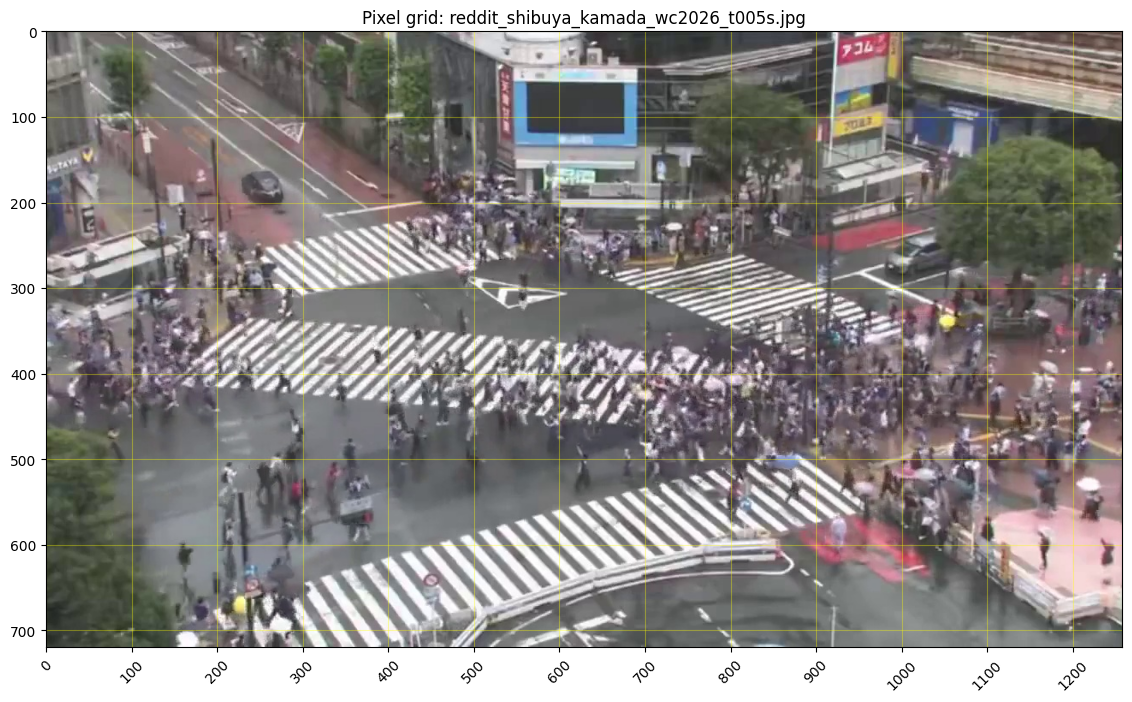

In [5]:
def show_reference_with_pixel_grid(frame_path, grid_step=100, figsize=(14, 8)):
    if not OPENCV_AVAILABLE:
        print("OpenCV unavailable; cannot load image.")
        return
    if not Path(frame_path).exists():
        print("Frame does not exist yet:", frame_path)
        return

    image_bgr = cv2.imread(str(frame_path))
    if image_bgr is None:
        print("Could not load frame:", frame_path)
        return

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    h, w = image_rgb.shape[:2]

    plt.figure(figsize=figsize)
    plt.imshow(image_rgb)
    plt.xticks(np.arange(0, w + 1, grid_step), rotation=45)
    plt.yticks(np.arange(0, h + 1, grid_step))
    plt.grid(color="yellow", alpha=0.35)
    plt.xlim(0, w)
    plt.ylim(h, 0)
    plt.title(f"Pixel grid: {Path(frame_path).name}")
    plt.show()


show_reference_with_pixel_grid(REFERENCE_FRAME_PATH, grid_step=100)

### 7. Select Homography Points Manually

Homography converts video pixels into ground-plane metres. Use only points on the flat road/crosswalk surface. Avoid people, traffic lights, building edges, signs, and anything above the ground plane.

For supervisor review, do not invent exact dimensions. Fill `x_m` and `y_m` only after measuring the matching points from a map/aerial reference or after getting dimensions confirmed.

In [6]:
POINT_COLUMNS = ["point_id", "x_px", "y_px", "x_m", "y_m", "notes"]

point_table = pd.DataFrame([
    ["P1", np.nan, np.nan, np.nan, np.nan, "road-plane point; fill pixel and metre coordinates"],
    ["P2", np.nan, np.nan, np.nan, np.nan, "road-plane point; fill pixel and metre coordinates"],
    ["P3", np.nan, np.nan, np.nan, np.nan, "road-plane point; fill pixel and metre coordinates"],
    ["P4", np.nan, np.nan, np.nan, np.nan, "road-plane point; fill pixel and metre coordinates"],
    ["P5", np.nan, np.nan, np.nan, np.nan, "optional extra point for a more stable fit"],
    ["P6", np.nan, np.nan, np.nan, np.nan, "optional extra point for a more stable fit"],
], columns=POINT_COLUMNS)

POINT_TABLE_PATH = POINTS_DIR / f"{VIDEO_ID}_homography_points.csv"
if POINT_TABLE_PATH.exists():
    point_table = pd.read_csv(POINT_TABLE_PATH)
    for col in POINT_COLUMNS:
        if col not in point_table.columns:
            point_table[col] = np.nan
    point_table = point_table[POINT_COLUMNS]
else:
    point_table.to_csv(POINT_TABLE_PATH, index=False)
    print("Created blank point table:", POINT_TABLE_PATH)

display(point_table)

Created blank point table: C:\Users\kylet\HTX\Deliverable 1\Documentation\Task 1 - NTU Paper + GABM\data\shibuya_reddit\homography_points\reddit_shibuya_kamada_wc2026_homography_points.csv


,point_id,x_px,y_px,x_m,y_m,notes
0,P1,NaN,NaN,NaN,NaN,road-plane point; fill pixel and metre coordin...
1,P2,NaN,NaN,NaN,NaN,road-plane point; fill pixel and metre coordin...
2,P3,NaN,NaN,NaN,NaN,road-plane point; fill pixel and metre coordin...
3,P4,NaN,NaN,NaN,NaN,road-plane point; fill pixel and metre coordin...
4,P5,NaN,NaN,NaN,NaN,optional extra point for a more stable fit
5,P6,NaN,NaN,NaN,NaN,optional extra point for a more stable fit


### 7.1 Optional Coordinate Picker

If reading coordinates from the grid is too slow, run `coords.py` from a terminal. It opens a small OpenCV window and saves selected pixel points to CSV.

In [7]:
def relative_or_absolute(path, base=PROJECT_DIR):
    path = Path(path).resolve()
    try:
        return str(path.relative_to(base.resolve()))
    except ValueError:
        return str(path)


coords_command = (
    f'python coords.py "{relative_or_absolute(REFERENCE_FRAME_PATH)}" '
    f'--out "{relative_or_absolute(POINT_TABLE_PATH)}" --n 6'
)
print("Run this from the project/notebook folder if you want click-based point selection:")
print(coords_command)

Run this from the project/notebook folder if you want click-based point selection:
python coords.py "data\shibuya_reddit\frames\reddit_shibuya_kamada_wc2026_t005s.jpg" --out "data\shibuya_reddit\homography_points\reddit_shibuya_kamada_wc2026_homography_points.csv" --n 6


### 8. Compute Homography

This cell uses all rows with complete `x_px`, `y_px`, `x_m`, and `y_m`. At least four valid point pairs are required.

In [ ]:
def validate_point_table(points_df):
    required = ["x_px", "y_px", "x_m", "y_m"]
    missing = [col for col in required if col not in points_df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    clean = points_df.dropna(subset=required).copy()
    if len(clean) < 4:
        return clean, f"Need at least 4 complete point pairs; currently have {len(clean)}."
    return clean, None


def compute_homography(points_df):
    clean, message = validate_point_table(points_df)
    if message is not None:
        return None, clean, message
    if not OPENCV_AVAILABLE:
        return None, clean, "OpenCV unavailable."

    image_points = clean[["x_px", "y_px"]].to_numpy(dtype=np.float32)
    world_points = clean[["x_m", "y_m"]].to_numpy(dtype=np.float32)
    H, status = cv2.findHomography(image_points, world_points, method=0)
    if H is None:
        return None, clean, "Homography failed. Recheck point ordering and coordinates."
    return H, clean, None


H_img_to_world, homography_points, homography_message = compute_homography(point_table)
if homography_message:
    print(homography_message)
else:
    print("Homography image -> world matrix:")
    print(H_img_to_world)
    display(homography_points)

### 9. Test Point Mapping

After homography is available, this reports residual error on the calibration points. Large residuals usually mean a point is not on the same ground plane, the point order is inconsistent, or the real-world coordinates are wrong.

In [ ]:
def pixels_to_world(points_px, H):
    if H is None or not OPENCV_AVAILABLE:
        return np.full((len(points_px), 2), np.nan)
    points_px = np.asarray(points_px, dtype=np.float32).reshape(-1, 1, 2)
    points_m = cv2.perspectiveTransform(points_px, H)
    return points_m.reshape(-1, 2)


def homography_residual_report(points_df, H):
    if H is None or points_df.empty:
        return pd.DataFrame()

    mapped = pixels_to_world(points_df[["x_px", "y_px"]].to_numpy(), H)
    report = points_df.copy()
    report["pred_x_m"] = mapped[:, 0]
    report["pred_y_m"] = mapped[:, 1]
    report["error_m"] = np.sqrt((report["pred_x_m"] - report["x_m"]) ** 2 + (report["pred_y_m"] - report["y_m"]) ** 2)
    return report


residual_report = homography_residual_report(homography_points, H_img_to_world)
if residual_report.empty:
    print("No homography residuals yet. Fill the point table first.")
else:
    display(residual_report)
    print("Mean residual error (m):", residual_report["error_m"].mean())

### 10. Manual Pedestrian Track Template

After homography is ready, manually annotate a small number of pedestrians across several frames. This is enough for a pilot because the goal is to prove the calibration pathway before investing in automatic tracking.

Recommended minimum for review: 10 to 20 pedestrians, 5 to 10 observations each, across the green-man crowd movement window.

In [ ]:
TRACK_COLUMNS = ["video_id", "ped_id", "frame", "time_s", "x_px", "y_px", "visibility", "notes"]
TRACK_PATH = ANNOTATION_DIR / f"{VIDEO_ID}_manual_tracks.csv"

if TRACK_PATH.exists():
    manual_tracks_px = pd.read_csv(TRACK_PATH)
    for col in TRACK_COLUMNS:
        if col not in manual_tracks_px.columns:
            manual_tracks_px[col] = np.nan
    manual_tracks_px = manual_tracks_px[TRACK_COLUMNS]
else:
    manual_tracks_px = pd.DataFrame(columns=TRACK_COLUMNS)
    manual_tracks_px.to_csv(TRACK_PATH, index=False)
    print("Created blank manual track template:", TRACK_PATH)

print("Manual annotation file:", TRACK_PATH)
display(manual_tracks_px.head())

### 11. Convert Manual Tracks To World Coordinates

Once `x_px` and `y_px` are filled, this cell maps each pedestrian observation into metres. If `time_s` is blank, it is calculated from `frame / FPS`.

In [ ]:
def prepare_manual_tracks(track_df, fps=FPS):
    if track_df.empty:
        return track_df.copy()

    out = track_df.copy()
    for col in ["frame", "time_s", "x_px", "y_px"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "time_s" not in out.columns:
        out["time_s"] = np.nan
    if "frame" in out.columns:
        missing_time = out["time_s"].isna() & out["frame"].notna()
        out.loc[missing_time, "time_s"] = out.loc[missing_time, "frame"] / fps
    return out


def add_world_coordinates(track_df, H):
    out = track_df.copy()
    out["x_m"] = np.nan
    out["y_m"] = np.nan

    if out.empty:
        return out
    if H is None:
        print("Homography is not ready, so world coordinates remain blank.")
        return out

    valid = out[["x_px", "y_px"]].notna().all(axis=1)
    if valid.any():
        mapped = pixels_to_world(out.loc[valid, ["x_px", "y_px"]].to_numpy(), H)
        out.loc[valid, "x_m"] = mapped[:, 0]
        out.loc[valid, "y_m"] = mapped[:, 1]
    return out


manual_tracks_px = prepare_manual_tracks(manual_tracks_px, fps=FPS)
tracks_world = add_world_coordinates(manual_tracks_px, H_img_to_world)
display(tracks_world.head())

### 12. Compute Speed And Direction

For SFM, speed estimates the desired speed distribution and direction helps separate crossing streams.

In [ ]:
def compute_track_kinematics(tracks_world, min_dt=1e-6):
    if tracks_world.empty:
        return pd.DataFrame()

    required = ["video_id", "ped_id", "time_s", "x_m", "y_m"]
    missing = [col for col in required if col not in tracks_world.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    out = tracks_world.dropna(subset=["ped_id", "time_s", "x_m", "y_m"]).copy()
    if out.empty:
        return out

    out = out.sort_values(["video_id", "ped_id", "time_s"])
    group_cols = ["video_id", "ped_id"]
    out["prev_x_m"] = out.groupby(group_cols)["x_m"].shift(1)
    out["prev_y_m"] = out.groupby(group_cols)["y_m"].shift(1)
    out["prev_time_s"] = out.groupby(group_cols)["time_s"].shift(1)
    out["dx_m"] = out["x_m"] - out["prev_x_m"]
    out["dy_m"] = out["y_m"] - out["prev_y_m"]
    out["dt_s"] = out["time_s"] - out["prev_time_s"]
    out.loc[out["dt_s"] <= min_dt, "dt_s"] = np.nan
    out["step_distance_m"] = np.sqrt(out["dx_m"] ** 2 + out["dy_m"] ** 2)
    out["speed_mps"] = out["step_distance_m"] / out["dt_s"]
    out["direction_deg"] = np.degrees(np.arctan2(out["dy_m"], out["dx_m"]))
    return out


kinematics = compute_track_kinematics(tracks_world)
if kinematics.empty:
    print("No kinematics yet. Fill homography points and manual tracks first.")
else:
    display(kinematics.head())

### 13. Summarise Observed Movement Metrics

The first useful SFM targets are walking speed distribution and direction spread. Speeds above 4 m/s are excluded as likely annotation or calibration errors for a first-pass pedestrian model.

In [ ]:
def summarise_speeds(kinematics, max_speed=4.0):
    if kinematics.empty or "speed_mps" not in kinematics.columns:
        return pd.DataFrame()

    clean = kinematics.replace([np.inf, -np.inf], np.nan).dropna(subset=["speed_mps"])
    clean = clean[(clean["speed_mps"] >= 0) & (clean["speed_mps"] <= max_speed)]
    if clean.empty:
        return pd.DataFrame()

    return pd.DataFrame([{
        "video_id": VIDEO_ID,
        "n_speed_observations": len(clean),
        "n_pedestrians": clean["ped_id"].nunique(),
        "mean_speed_mps": clean["speed_mps"].mean(),
        "median_speed_mps": clean["speed_mps"].median(),
        "std_speed_mps": clean["speed_mps"].std(),
        "p10_speed_mps": clean["speed_mps"].quantile(0.10),
        "p90_speed_mps": clean["speed_mps"].quantile(0.90),
        "mean_direction_deg": clean["direction_deg"].mean(),
    }])


speed_summary = summarise_speeds(kinematics)
if speed_summary.empty:
    print("No speed summary yet.")
else:
    display(speed_summary)

### 14. Estimate Nearest-Neighbour Spacing

Spacing is a proxy for personal space and crowd compactness. In SFM terms, this helps tune pedestrian radius and repulsive-force strength.

In [ ]:
def nearest_neighbour_spacing(tracks_world, time_round_s=0.5):
    if tracks_world.empty:
        return pd.DataFrame()

    df = tracks_world.dropna(subset=["ped_id", "time_s", "x_m", "y_m"]).copy()
    if df.empty:
        return pd.DataFrame()

    df["time_bin_s"] = (df["time_s"] / time_round_s).round() * time_round_s
    rows = []
    for (video_id, time_bin), group in df.groupby(["video_id", "time_bin_s"]):
        if len(group) < 2:
            continue
        coords = group[["x_m", "y_m"]].to_numpy(dtype=float)
        ped_ids = group["ped_id"].to_list()
        diff = coords[:, None, :] - coords[None, :, :]
        dist = np.sqrt((diff ** 2).sum(axis=2))
        np.fill_diagonal(dist, np.nan)
        nn = np.nanmin(dist, axis=1)
        for ped_id, nn_m in zip(ped_ids, nn):
            rows.append({"video_id": video_id, "time_bin_s": time_bin, "ped_id": ped_id, "nn_spacing_m": nn_m})
    return pd.DataFrame(rows)


spacing = nearest_neighbour_spacing(tracks_world)
if spacing.empty:
    print("No spacing estimates yet.")
else:
    spacing_summary = spacing.groupby("video_id", as_index=False).agg(
        mean_nn_spacing_m=("nn_spacing_m", "mean"),
        median_nn_spacing_m=("nn_spacing_m", "median"),
        p10_nn_spacing_m=("nn_spacing_m", lambda s: s.quantile(0.10)),
    )
    display(spacing_summary)

### 15. Estimate Flow Across A Measurement Line

Flow checks whether the SFM can reproduce throughput, not only individual walking speed. Set the axis and line value after the world coordinate system is defined.

In [ ]:
def compute_line_flow(kinematics, axis="x", line_value=0.0, bin_s=1.0):
    if kinematics.empty:
        return pd.DataFrame()

    pos_col = f"{axis}_m"
    prev_col = f"prev_{axis}_m"
    if pos_col not in kinematics.columns or prev_col not in kinematics.columns:
        raise ValueError(f"Expected columns {pos_col} and {prev_col}")

    df = kinematics.dropna(subset=[pos_col, prev_col, "time_s", "ped_id"]).copy()
    if df.empty:
        return pd.DataFrame()

    crossed = ((df[prev_col] - line_value) * (df[pos_col] - line_value)) <= 0
    crossings = df[crossed].copy()
    if crossings.empty:
        return pd.DataFrame()

    crossings["time_bin_s"] = np.floor(crossings["time_s"] / bin_s) * bin_s
    flow = crossings.groupby(["video_id", "time_bin_s"], as_index=False)["ped_id"].nunique()
    flow = flow.rename(columns={"ped_id": "crossings"})
    flow["flow_p_per_s"] = flow["crossings"] / bin_s
    return flow


FLOW_AXIS = "x"
FLOW_LINE_VALUE_M = 0.0
flow = compute_line_flow(kinematics, axis=FLOW_AXIS, line_value=FLOW_LINE_VALUE_M, bin_s=1.0)
if flow.empty:
    print("No flow estimate yet. Define world coordinates, tracks, and a meaningful measurement line first.")
else:
    display(flow.head())

### 16. Save Calibration Targets

This table is the bridge back to SFM calibration: observed video metrics become target values for simulation comparison.

In [ ]:
def combine_calibration_targets(speed_summary, spacing=None, flow=None):
    if speed_summary is None or speed_summary.empty:
        return pd.DataFrame()

    out = speed_summary.copy()

    if spacing is not None and not spacing.empty:
        spacing_summary = spacing.groupby("video_id", as_index=False).agg(
            mean_nn_spacing_m=("nn_spacing_m", "mean"),
            median_nn_spacing_m=("nn_spacing_m", "median"),
        )
        out = out.merge(spacing_summary, on="video_id", how="left")

    if flow is not None and not flow.empty:
        flow_summary = flow.groupby("video_id", as_index=False).agg(
            mean_flow_p_per_s=("flow_p_per_s", "mean"),
            max_flow_p_per_s=("flow_p_per_s", "max"),
        )
        out = out.merge(flow_summary, on="video_id", how="left")

    return out


calibration_targets = combine_calibration_targets(speed_summary, spacing, flow)
if calibration_targets.empty:
    print("No calibration target CSV saved yet because manual calibration values are incomplete.")
else:
    out_path = OUTPUT_DIR / f"{VIDEO_ID}_manual_calibration_targets.csv"
    calibration_targets.to_csv(out_path, index=False)
    print("Saved:", out_path)
    display(calibration_targets)

### 17. How These Metrics Map To The Social Force Model

| Observed quantity | How this notebook computes it | SFM relevance |
|---|---|---|
| Position in metres | Homography maps `(x_px, y_px)` to `(x_m, y_m)` | Required for simulation-state comparison |
| Walking speed | Per-pedestrian displacement over time | Calibrates desired speed `v0` and speed variance |
| Direction angle | `atan2(dy, dx)` after world mapping | Defines crossing streams and target directions |
| Nearest-neighbour spacing | Minimum distance to another pedestrian in the same time bin | Tunes personal space, pedestrian radius, and repulsive force |
| Flow | Count of pedestrians crossing a virtual world-coordinate line | Validates collective throughput |

Once the manual values are filled, the SFM run should produce the same output columns, then compare simulated and observed metrics using a simple weighted error.

In [ ]:
SFM_PARAMETER_LINKS = pd.DataFrame([
    {"parameter": "desired_speed_mean", "target_metric": "mean_speed_mps", "why_it_matters": "average preferred walking pace"},
    {"parameter": "desired_speed_std", "target_metric": "std_speed_mps", "why_it_matters": "variation between pedestrians"},
    {"parameter": "relaxation_time", "target_metric": "speed change smoothness", "why_it_matters": "how quickly agents adapt velocity"},
    {"parameter": "pedestrian_radius", "target_metric": "median_nn_spacing_m", "why_it_matters": "minimum comfortable body spacing"},
    {"parameter": "social_force_factor", "target_metric": "mean_nn_spacing_m", "why_it_matters": "strength of repulsion in dense crowds"},
    {"parameter": "goal / route layout", "target_metric": "mean_flow_p_per_s", "why_it_matters": "whether throughput matches observed crossing movement"},
])

display(SFM_PARAMETER_LINKS)

### 18. Supervisor Checkpoint

For this notebook, it is enough to show:

1. the World Cup Shibuya video is downloaded and readable,
2. reference frames can be extracted reproducibly,
3. homography points have a clear manual table and coordinate-picker option,
4. pedestrian annotation has a reusable CSV template,
5. the code path converts manual tracks into SFM calibration targets.

Stop here until supervisor feedback confirms the video source/licence is acceptable and the real-world crossing dimensions should be measured from map/aerial reference. The next work should not be automatic tracking or full SFM parameter search until those assumptions are approved.